In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency


colors = sns.color_palette('pastel')

In [19]:
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [20]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("Attrition")

In [21]:
chi2_statistic = {}
p_values = {}

# Perform chi-square test for each column
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['Attrition'])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    chi2_statistic[col] = chi2
    p_values[col] = p_value


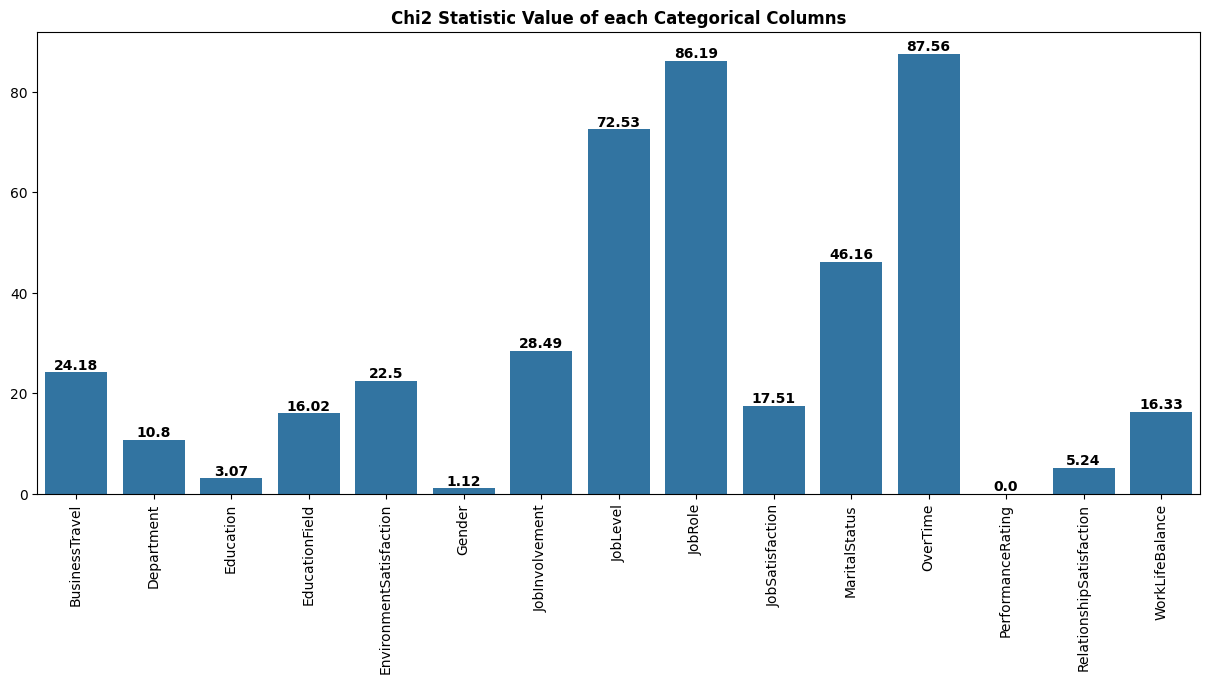

In [22]:
columns = list(chi2_statistic.keys())
values = list(chi2_statistic.values())

plt.figure(figsize=(15,6))
sns.barplot(x=columns, y=values)
plt.xticks(rotation=90)
plt.title("Chi2 Statistic Value of each Categorical Columns",fontweight="black")
for index,value in enumerate(values):
    plt.text(index,value,round(value,2),ha="center",va="bottom",fontweight="black")

plt.show()

In [23]:
test_df = pd.DataFrame({"Features":columns,"Chi_2 Statistic":values})
test_df["P_value"] =  [format(p, '.20f') for p in list(p_values.values())]
test_df = test_df.sort_values(by="Chi_2 Statistic", ascending=False)
test_df

,Features,Chi_2 Statistic,P_value
11,OverTime,87.564294,0.00000000000000000001
8,JobRole,86.190254,0.00000000000000275248
7,JobLevel,72.529013,0.00000000000000663468
10,MaritalStatus,46.163677,0.00000000009455511060
6,JobInvolvement,28.492021,0.00000286318063671342
0,BusinessTravel,24.182414,0.00000560861447644993
4,EnvironmentSatisfaction,22.503881,0.00005123468906289431
9,JobSatisfaction,17.505077,0.00055630045103875563
14,WorkLifeBalance,16.325097,0.00097256988453488214
3,EducationField,16.024674,0.00677398013902520690


# Conclusion

### Employee Attrition is significantly associated with these features statistically
- Over Time
- Job Role
- Job Level
- Marital Status
- Job Involvement
- Business Travel
- Environment Satisfaction
- Job Satisfaction
- Work-Life Balance
- Education Field
- Department

### Employee Attrition is not significantly associated with these features statistically
- Relationship Satisfaction
- Education
- Gender
- Performance Rating

In [24]:
# Get insignificant columns (p-value >= 0.05)
insignificant_cols = [col for col, p in p_values.items() if p >= 0.05]
print("Insignificant Columns:", insignificant_cols)

# Drop them from the dataframe
df = df.drop(columns=insignificant_cols)
print("Remaining Columns:", df.columns.tolist())

Insignificant Columns: ['Education', 'Gender', 'PerformanceRating', 'RelationshipSatisfaction']
Remaining Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'EducationField', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [25]:
# Check for duplicates in the dataset
df_duplicates = df[df.duplicated()]

# Display the duplicate rows in the dataset, if any
if not df_duplicates.empty:
    print("Duplicate Rows in Dataset:")
    display(df_duplicates)  # Display the duplicated dataframe
else:
    print("No Duplicate Rows in Dataset")

No Duplicate Rows in Dataset


In [26]:
df.to_csv('../data/Processed_HR_Employee_Attrition-v2.csv', index=False)  